In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [19]:
features_df = pd.read_csv('ecommerce_customer_features.csv')
targets_df = pd.read_csv('ecommerce_customer_targets.csv')
print("Features",features_df)
print("Targets", targets_df)

Features                                Customer_ID  account_age_months  \
0     0520df14-712d-4c69-a0c5-95a2e7dfc1ff                  46   
1     a4013b3f-0688-4096-a194-6074be8ffec8                   3   
2     eb870f2c-ed3d-4a21-a8ac-273fae69ea4f                  29   
3     a7433451-8ea9-428a-9d80-679c6963b39f                  35   
4     43f81935-49e3-44d3-94d1-5c4715738988                  39   
...                                    ...                 ...   
5995  7e6f01d6-a7bb-429e-91d1-7c929547852b                   2   
5996  4874448f-192d-4c5a-a21b-80d02b70c0e4                  52   
5997  6a5b9ad3-7488-40e9-95b7-ad0ea7354f51                   8   
5998  3306b81f-13df-4ae9-947d-deaaf7723279                   4   
5999  48867913-4bb5-4823-87f0-dd405e3970e4                   9   

      avg_order_value  total_orders  days_since_last_purchase  \
0              164.96            12                        17   
1               39.09             4                         5   
2  

In [20]:
df_task3 = pd.merge(features_df, targets_df, on='Customer_ID')

Total Customers: 6000
Current Churn Rate: 15.48%


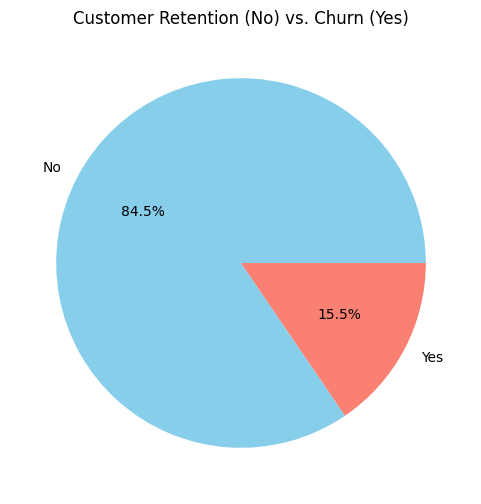

In [21]:
churn_counts = df_task3['churned'].value_counts()
churn_rate = (churn_counts['Yes'] / len(df_task3)) * 100

print(f"Total Customers: {len(df_task3)}")
print(f"Current Churn Rate: {churn_rate:.2f}%")

# Visualize the balance (Your Pie Chart)
plt.figure(figsize=(6, 6))
df_task3['churned'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Customer Retention (No) vs. Churn (Yes)')
plt.show()

In [22]:
df_task3['loyalty_member'] = df_task3['loyalty_member'].map({'Yes': 1, 'No': 0})
df_task3['churned'] = df_task3['churned'].map({'Yes': 1, 'No': 0})

X = df_task3.drop(['Customer_ID', 'churned'], axis=1)
y = df_task3['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_churn = RandomForestClassifier(n_estimators=100, random_state=42)
model_churn.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric


--- Task 3 Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1007
           1       0.94      0.84      0.89       193

    accuracy                           0.97      1200
   macro avg       0.96      0.92      0.94      1200
weighted avg       0.97      0.97      0.97      1200



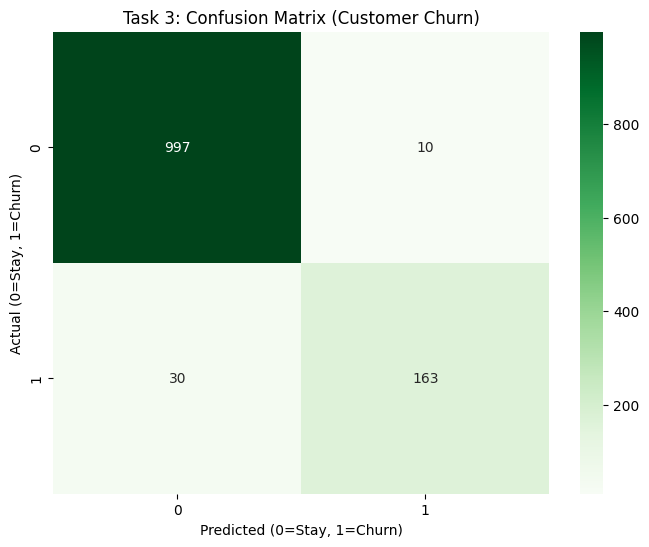

In [23]:
y_pred = model_churn.predict(X_test)

print("\n--- Task 3 Classification Report ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Task 3: Confusion Matrix (Customer Churn)')
plt.xlabel('Predicted (0=Stay, 1=Churn)')
plt.ylabel('Actual (0=Stay, 1=Churn)')
plt.show()